# OTT 멤버십 전처리 + EDA

**단계별 전처리 후 각 단계 결과 확인 → 최종 EDA**

| 단계 | 내용 |
|---|---|
| 필수 1 | user_no 중복 제거 (duration_days 최대 유지) |
| 필수 2 | 타겟 인코딩 (repurchase / promotion_yn / is_churn_prevented) |
| 필수 3 | 통화 통일 (iOS 달러 → KRW) |
| 필수 4 | is_user_verified 인코딩 |
| 필수 5 | concurrent_streams 이상값·결측 제거 |
| 필수 6 | View_History only 유저 확인 |
| 권장 1 | age > 100 이상값 처리 + 결측 대체 |
| 권장 2 | billing_method 4그룹 그루핑 |
| 권장 3 | gender=N → 결측 처리 + 비율 대체 |
| 파생   | plan_tier, currency_type, 이진 피처 |
| 선택   | View_History 집계 피처 |

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA   = '../../_data/01_raw/'
BLUE   = '#2962a2'
ORANGE = '#f59e0b'
GREEN  = '#43a047'
RED    = '#e53935'
GRAY   = '#90a4ae'
print('준비 완료')

준비 완료


In [16]:
mem_raw = pd.read_csv(DATA + 'Membership.csv')
um      = pd.read_csv(DATA + 'User_Mapping.csv')
vh      = pd.read_csv(DATA + 'View_History.csv')

mem_raw['reg_date']      = pd.to_datetime(mem_raw['reg_date'])
mem_raw['end_date']      = pd.to_datetime(mem_raw['end_date'])
mem_raw['duration_days'] = (mem_raw['end_date'] - mem_raw['reg_date']).dt.days

print(f'Membership  : {mem_raw.shape}')
print(f'User_Mapping: {um.shape}  columns={um.columns.tolist()}')
print(f'View_History: {vh.shape}')
print('원본 컬럼:', mem_raw.columns.tolist())

mem = mem_raw.copy()

Membership  : (18183, 16)
User_Mapping: (19877, 2)  columns=['uid', 'USER_ID']
View_History: (106205, 5)
원본 컬럼: ['user_no', 'product_cd', 'amount', 'billing_method', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_date', 'reg_hour', 'end_date', 'duration_days']


In [17]:
print('=== 전처리 전 현황 ===')
print(f'총 행수      : {len(mem):,}')
print(f'user_no 중복 : {mem["user_no"].duplicated().sum():,}건')
print()
miss = mem.isnull().sum()
print('결측치:')
print(miss[miss > 0].to_string())
print()
print('concurrent_streams:', mem['concurrent_streams'].value_counts(dropna=False).to_dict())
print('repurchase        :', mem['repurchase'].value_counts(dropna=False).to_dict())
print('gender            :', mem['gender'].value_counts(dropna=False).to_dict())

=== 전처리 전 현황 ===
총 행수      : 18,183
user_no 중복 : 338건

결측치:
concurrent_streams       70
promotion_yn           8980
is_churn_prevented    14926
repurchase             6252
is_user_verified        600
gender                  164
age                     164

concurrent_streams: {1.0: 11354, 2.0: 3804, 4.0: 2948, nan: 70, 3.0: 7}
repurchase        : {'O': 11931, nan: 6252}
gender            : {'F': 9479, 'M': 5691, 'N': 2849, nan: 164}


---
## 필수 전처리

In [18]:
# 필수 1 | user_no 중복 제거 (duration_days 최대값 행 유지)
before = len(mem)
dup_rows = mem[mem.duplicated('user_no', keep=False)]
print(f'중복 user_no 보유 행: {len(dup_rows):,}건 ({dup_rows["user_no"].nunique():,}명)')

mem = (
    mem.sort_values('duration_days', ascending=False, na_position='last')
       .drop_duplicates(subset='user_no', keep='first')
       .reset_index(drop=True)
)
print(f'→ {before:,} → {len(mem):,}  (제거 {before - len(mem):,}건)')

중복 user_no 보유 행: 633건 (295명)
→ 18,183 → 17,845  (제거 338건)


In [19]:
# 필수 2 | 타겟 인코딩 : O → 1, NaN → 0
for col in ['repurchase', 'promotion_yn', 'is_churn_prevented']:
    mem[col] = mem[col].map({'O': 1}).fillna(0).astype(int)

print('repurchase        :', mem['repurchase'].value_counts().to_dict())
print('promotion_yn      :', mem['promotion_yn'].value_counts().to_dict())
print('is_churn_prevented:', mem['is_churn_prevented'].value_counts().to_dict())

repurchase        : {1: 11889, 0: 5956}
promotion_yn      : {1: 9137, 0: 8708}
is_churn_prevented: {0: 14645, 1: 3200}


In [20]:
# 필수 3 | 통화 통일 : iOS 달러 → KRW (2021 평균 환율 1,144원)
# 대상: product_cd in {pk_1506, pk_1507, pk_1508}
# amount == 100 (프로모션 가격, 이미 KRW 100원) 제외
USD_PRODUCTS = {'pk_1506', 'pk_1507', 'pk_1508'}
USD_TO_KRW   = 1144

usd_mask = mem['product_cd'].isin(USD_PRODUCTS) & (mem['amount'] != 100)
print(f'USD 변환 대상: {usd_mask.sum():,}건')
print('변환 전 금액 샘플:', sorted(mem.loc[usd_mask, 'amount'].unique())[:8])

mem.loc[usd_mask, 'amount'] = (
    mem.loc[usd_mask, 'amount'] * USD_TO_KRW
).round().astype(int)

print('변환 후 금액 샘플:', sorted(mem.loc[usd_mask, 'amount'].unique())[:8])
print(f'amount 범위: {mem["amount"].min():,} ~ {mem["amount"].max():,}')

USD 변환 대상: 2,860건
변환 전 금액 샘플: [9.99, 13.49, 16.49]
변환 후 금액 샘플: [11429.0, 15433.0, 18865.0]
amount 범위: 7.69 ~ 18,865.0


In [21]:
# 필수 4 | is_user_verified : 결측 → N 대체, Y → 1 / N → 0
mem['is_user_verified'] = mem['is_user_verified'].fillna('N')
mem['is_verified']      = (mem['is_user_verified'] == 'Y').astype(int)
print('is_verified:', mem['is_verified'].value_counts().to_dict())

is_verified: {1: 13306, 0: 4539}


In [22]:
# 필수 5 | concurrent_streams : =3 이상값 제거 + 결측 행 제거
before = len(mem)
n3  = (mem['concurrent_streams'] == 3).sum()
nna = mem['concurrent_streams'].isna().sum()

mem = mem[mem['concurrent_streams'] != 3]
mem = mem.dropna(subset=['concurrent_streams'])
mem['concurrent_streams'] = mem['concurrent_streams'].astype(int)
mem = mem.reset_index(drop=True)

print(f'=3 제거: {n3}건 / 결측 제거: {nna}건')
print(f'→ {before:,} → {len(mem):,}')
print('concurrent_streams:', mem['concurrent_streams'].value_counts().to_dict())

=3 제거: 7건 / 결측 제거: 59건
→ 17,845 → 17,779
concurrent_streams: {1: 11107, 2: 3742, 4: 2930}


In [23]:
# 필수 6 | View_History only 유저 확인
# 조인 경로: USER_ID → uid(User_Mapping) → user_no(Membership)
vh_uid  = (
    vh[['USER_ID']].drop_duplicates()
      .merge(um[['USER_ID', 'uid']], on='USER_ID', how='left')
)
vh_only = vh_uid[~vh_uid['uid'].isin(mem['user_no'])]
print(f'View_History 유저 수  : {vh_uid["USER_ID"].nunique():,}명')
print(f'Membership 미매핑     : {len(vh_only):,}명 → 집계 피처 생성 시 제외됨')
print('Membership 기준이므로 행 제거 없음')

View_History 유저 수  : 14,892명
Membership 미매핑     : 60명 → 집계 피처 생성 시 제외됨
Membership 기준이므로 행 제거 없음


---
## 권장 전처리

In [24]:
# 권장 1 | age > 100 → NaN + 연령대 비율 기반 랜덤 대체
n_out = (mem['age'] > 100).sum()
n_na  = mem['age'].isna().sum()
print(f'age > 100: {n_out}건 / NaN: {n_na}건')

mem.loc[mem['age'] > 100, 'age'] = np.nan

valid_ages = mem['age'].dropna().astype(int)
age_dist   = valid_ages.value_counts(normalize=True).sort_index()
null_idx   = mem[mem['age'].isna()].index

np.random.seed(42)
mem.loc[null_idx, 'age'] = np.random.choice(
    age_dist.index, size=len(null_idx), p=age_dist.values
)
mem['age'] = mem['age'].astype(int)

print(f'→ {len(null_idx):,}건 대체 완료  |  age 범위: {mem["age"].min()} ~ {mem["age"].max()}')

age > 100: 2건 / NaN: 150건
→ 152건 대체 완료  |  age 범위: 0 ~ 90


In [25]:
# 권장 2 | billing_method 4그룹 그루핑
def billing_group(val):
    if pd.isna(val): return '기타'
    s = str(int(val))
    if s.startswith('13'): return '국내카드'
    if s == '151':         return '간편결제'
    if s == '140':         return 'iOS'
    if s.startswith('18'): return '모바일'
    return '기타'

mem['billing_group'] = mem['billing_method'].apply(billing_group)
print(mem['billing_group'].value_counts().to_string())

billing_group
국내카드    8171
간편결제    3414
iOS     2921
모바일     1665
기타      1608


In [26]:
# 권장 3 | gender=N → NaN + F/M 비율 기반 랜덤 대체
# N = 미인증 기본값 (실제 성별 정보 없음)
n_N  = (mem['gender'] == 'N').sum()
n_na = mem['gender'].isna().sum()
print(f'gender=N: {n_N:,}건 / NaN: {n_na}건')

mem['gender']  = mem['gender'].replace('N', np.nan)
fm_dist        = mem['gender'].value_counts(normalize=True)
null_idx_g     = mem[mem['gender'].isna()].index

np.random.seed(42)
mem.loc[null_idx_g, 'gender'] = np.random.choice(
    fm_dist.index, size=len(null_idx_g), p=fm_dist.values
)
print(f'F/M 비율: {fm_dist.round(3).to_dict()}')
print(f'→ {len(null_idx_g):,}건 대체 완료')
print('최종 gender:', mem['gender'].value_counts().to_dict())

gender=N: 2,715건 / NaN: 150건
F/M 비율: {'F': 0.625, 'M': 0.375}
→ 2,865건 대체 완료
최종 gender: {'F': 11111, 'M': 6668}


---
## 파생 피처 생성

In [27]:
plan_map = {
    'pk_1487': 'basic',    'pk_2025': 'basic',    'pk_1508': 'basic',
    'pk_1488': 'standard', 'pk_2026': 'standard', 'pk_1506': 'standard',
    'pk_1489': 'premium',  'pk_2027': 'premium',  'pk_1507': 'premium',
}
mem['plan_tier']             = mem['product_cd'].map(plan_map).fillna('기타')
mem['currency_type']         = mem['product_cd'].apply(lambda x: 'USD' if x in USD_PRODUCTS else 'KRW')
mem['is_promotional_price']  = (mem['amount'] == 100).astype(int)
mem['is_night_signup']       = mem['reg_hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)
mem['reg_weekday']           = mem['reg_date'].dt.dayofweek
mem['is_same_day_cancel']    = (mem['duration_days'] == 0).astype(int)
mem['age_group']             = (mem['age'] // 10 * 10).astype(int)

print('plan_tier      :', mem['plan_tier'].value_counts().to_dict())
print('currency_type  :', mem['currency_type'].value_counts().to_dict())
print('is_promo_price :', mem['is_promotional_price'].value_counts().to_dict())
print('is_night_signup:', mem['is_night_signup'].value_counts().to_dict())
print('same_day_cancel:', mem['is_same_day_cancel'].value_counts().to_dict())

plan_tier      : {'basic': 10829, 'standard': 3734, 'premium': 2928, '기타': 288}
currency_type  : {'KRW': 14919, 'USD': 2860}
is_promo_price : {1: 9137, 0: 8642}
is_night_signup: {0: 12159, 1: 5620}
same_day_cancel: {0: 17582, 1: 197}


---
## View_History 집계 피처 (선택)
> 시청 기간 약 5주 (2021-03-01 ~ 04-05) → feature importance 낮을 수 있음

In [28]:
vh_agg = (
    vh.groupby('USER_ID')
      .agg(
          total_watch_count    = ('MOVIE_ID',  'count'),
          total_watch_duration = ('DURATION',  'sum'),
          unique_movies        = ('MOVIE_ID',  'nunique'),
          avg_duration         = ('DURATION',  'mean'),
          watch_days_count     = ('WATCH_DAY', 'nunique'),
      )
      .reset_index()
)
vh_agg = vh_agg.merge(um[['USER_ID', 'uid']], on='USER_ID', how='left')

vh_cols = ['uid', 'total_watch_count', 'total_watch_duration',
           'unique_movies', 'avg_duration', 'watch_days_count']
mem = mem.merge(vh_agg[vh_cols], left_on='user_no', right_on='uid', how='left')
mem.drop(columns=['uid'], inplace=True)

mem['has_watch_history'] = mem['total_watch_count'].notna().astype(int)
for c in ['total_watch_count', 'total_watch_duration', 'unique_movies',
          'avg_duration', 'watch_days_count']:
    mem[c] = mem[c].fillna(0)

print(f'시청이력 보유: {mem["has_watch_history"].sum():,}명 ({mem["has_watch_history"].mean()*100:.1f}%)')

시청이력 보유: 14,832명 (83.3%)


---
## 전처리 결과 요약

In [29]:
print('=' * 55)
print(f'  원본 행수   : {len(mem_raw):,}')
print(f'  최종 행수   : {len(mem):,}  (제거 {len(mem_raw)-len(mem):,}건)')
print(f'  최종 컬럼수 : {len(mem.columns)}')
print('=' * 55)
print()
print('타겟 분포:')
vc = mem['repurchase'].value_counts()
for k in [1, 0]:
    print(f'  {k} : {vc[k]:,}건  ({vc[k]/len(mem)*100:.1f}%)')
print()
print('잔여 결측치:')
miss = mem.isnull().sum()
left = miss[miss > 0]
print('  없음' if left.empty else left.to_string())
print()
print('컬럼 목록:')
print(mem.columns.tolist())

  원본 행수   : 18,183
  최종 행수   : 17,815  (제거 368건)
  최종 컬럼수 : 31

타겟 분포:
  1 : 11,869건  (66.6%)
  0 : 5,946건  (33.4%)

잔여 결측치:
  없음

컬럼 목록:
['user_no', 'product_cd', 'amount', 'billing_method', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_date', 'reg_hour', 'end_date', 'duration_days', 'is_verified', 'billing_group', 'plan_tier', 'currency_type', 'is_promotional_price', 'is_night_signup', 'reg_weekday', 'is_same_day_cancel', 'age_group', 'total_watch_count', 'total_watch_duration', 'unique_movies', 'avg_duration', 'watch_days_count', 'has_watch_history']


In [30]:
save_path = '../data/Membership_processing.csv'
mem.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {save_path}')

저장 완료: c:/Users/USER/OneDrive/바탕 화면/AX/data/Membership_clean.csv


---
## 전처리 후 EDA

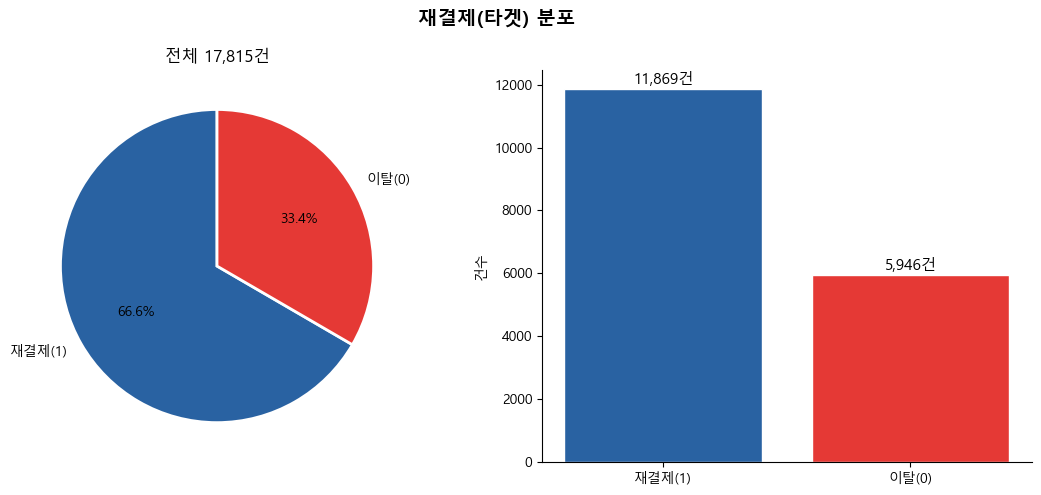

In [31]:
# 1. 타겟 분포
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('재결제(타겟) 분포', fontsize=14, fontweight='bold')
vc     = mem['repurchase'].value_counts()
vals   = [vc.get(1, 0), vc.get(0, 0)]
labels = ['재결제(1)', '이탈(0)']
colors = [BLUE, RED]
axes[0].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title(f'전체 {len(mem):,}건')
bars = axes[1].bar(labels, vals, color=colors, edgecolor='white')
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}건', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('건수')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

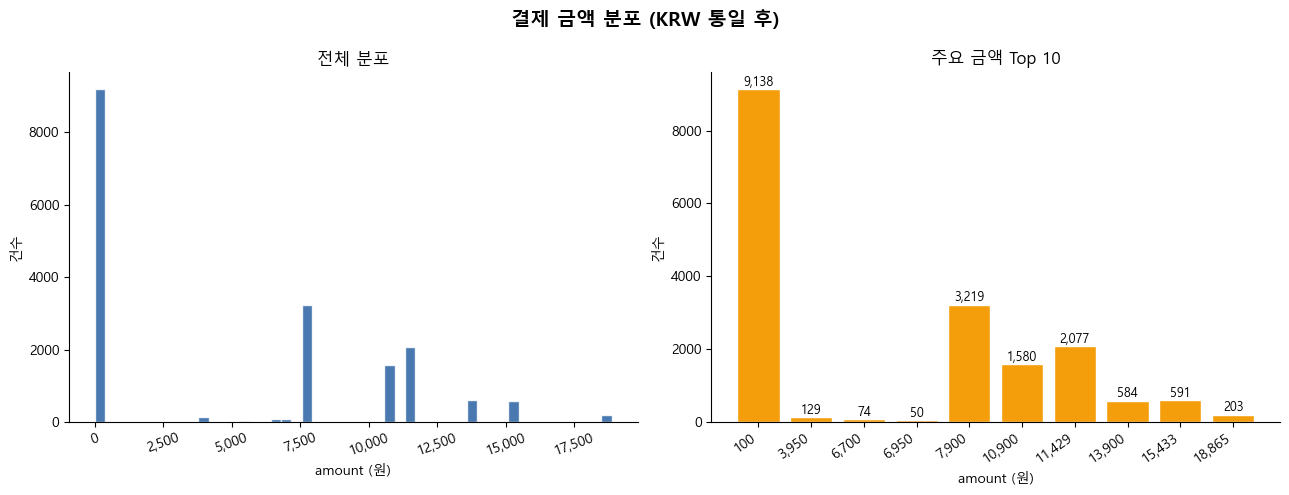

In [32]:
# 2. 결제 금액 분포 (KRW 통일 후)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('결제 금액 분포 (KRW 통일 후)', fontsize=14, fontweight='bold')
axes[0].hist(mem['amount'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('amount (원)')
axes[0].set_ylabel('건수')
axes[0].set_title('전체 분포')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=20)
axes[0].spines[['top', 'right']].set_visible(False)
top_amt = mem['amount'].value_counts().head(10).sort_index()
bars = axes[1].bar(range(len(top_amt)), top_amt.values, color=ORANGE, edgecolor='white')
axes[1].set_xticks(range(len(top_amt)))
axes[1].set_xticklabels([f'{int(x):,}' for x in top_amt.index], rotation=35, ha='right')
for bar, v in zip(bars, top_amt.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('amount (원)')
axes[1].set_ylabel('건수')
axes[1].set_title('주요 금액 Top 10')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

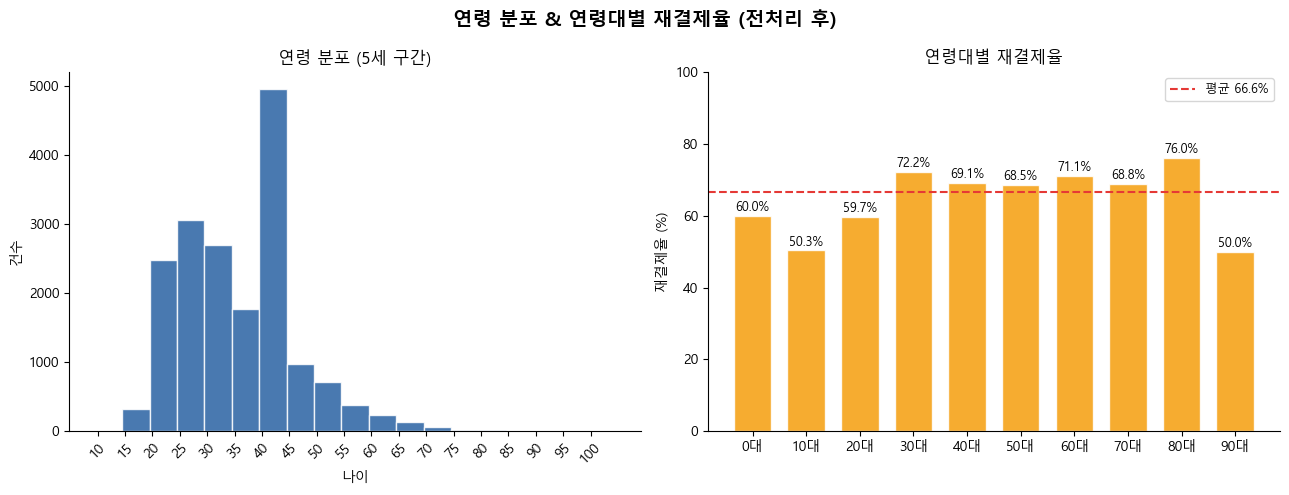

In [33]:
# 3. 연령 분포 & 연령대별 재결제율
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('연령 분포 & 연령대별 재결제율 (전처리 후)', fontsize=14, fontweight='bold')
age_bins = np.arange(10, 106, 5) - 0.5
axes[0].hist(mem['age'], bins=age_bins, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('나이')
axes[0].set_ylabel('건수')
axes[0].set_title('연령 분포 (5세 구간)')
axes[0].set_xticks(range(10, 105, 5))
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top', 'right']].set_visible(False)
ag = mem.groupby('age_group')['repurchase'].agg(['mean', 'count'])
ag['mean'] *= 100
bars = axes[1].bar(ag.index, ag['mean'], color=ORANGE, edgecolor='white', alpha=0.85, width=7)
axes[1].axhline(mem['repurchase'].mean()*100, color=RED, linestyle='--', linewidth=1.5,
                label=f'평균 {mem["repurchase"].mean()*100:.1f}%')
for bar, (idx, row) in zip(bars, ag.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{row["mean"]:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(ag.index)
axes[1].set_xticklabels([f'{x}대' for x in ag.index])
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('재결제율 (%)')
axes[1].set_title('연령대별 재결제율')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

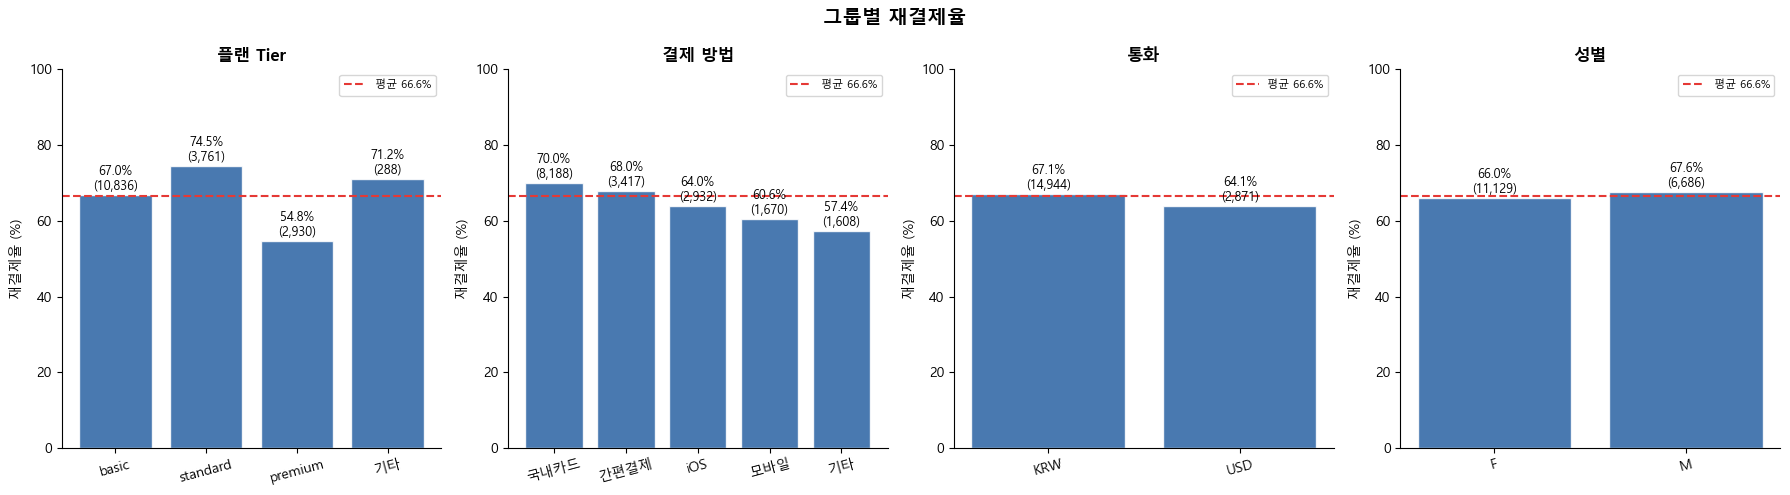

In [34]:
# 4. 그룹별 재결제율
groups = [
    ('plan_tier',    '플랜 Tier',  ['basic', 'standard', 'premium', '기타']),
    ('billing_group','결제 방법',  ['국내카드', '간편결제', 'iOS', '모바일', '기타']),
    ('currency_type','통화',       ['KRW', 'USD']),
    ('gender',       '성별',       ['F', 'M']),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('그룹별 재결제율', fontsize=14, fontweight='bold')
avg = mem['repurchase'].mean() * 100
for ax, (col, title, order) in zip(axes, groups):
    existing = [x for x in order if x in mem[col].unique()]
    rates    = mem.groupby(col)['repurchase'].mean().reindex(existing) * 100
    counts   = mem[col].value_counts().reindex(existing)
    bars = ax.bar(existing, rates.values, color=BLUE, edgecolor='white', alpha=0.85)
    ax.axhline(avg, color=RED, linestyle='--', linewidth=1.5, label=f'평균 {avg:.1f}%')
    for bar, v, cnt in zip(bars, rates.values, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}%\n({cnt:,})', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('재결제율 (%)')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

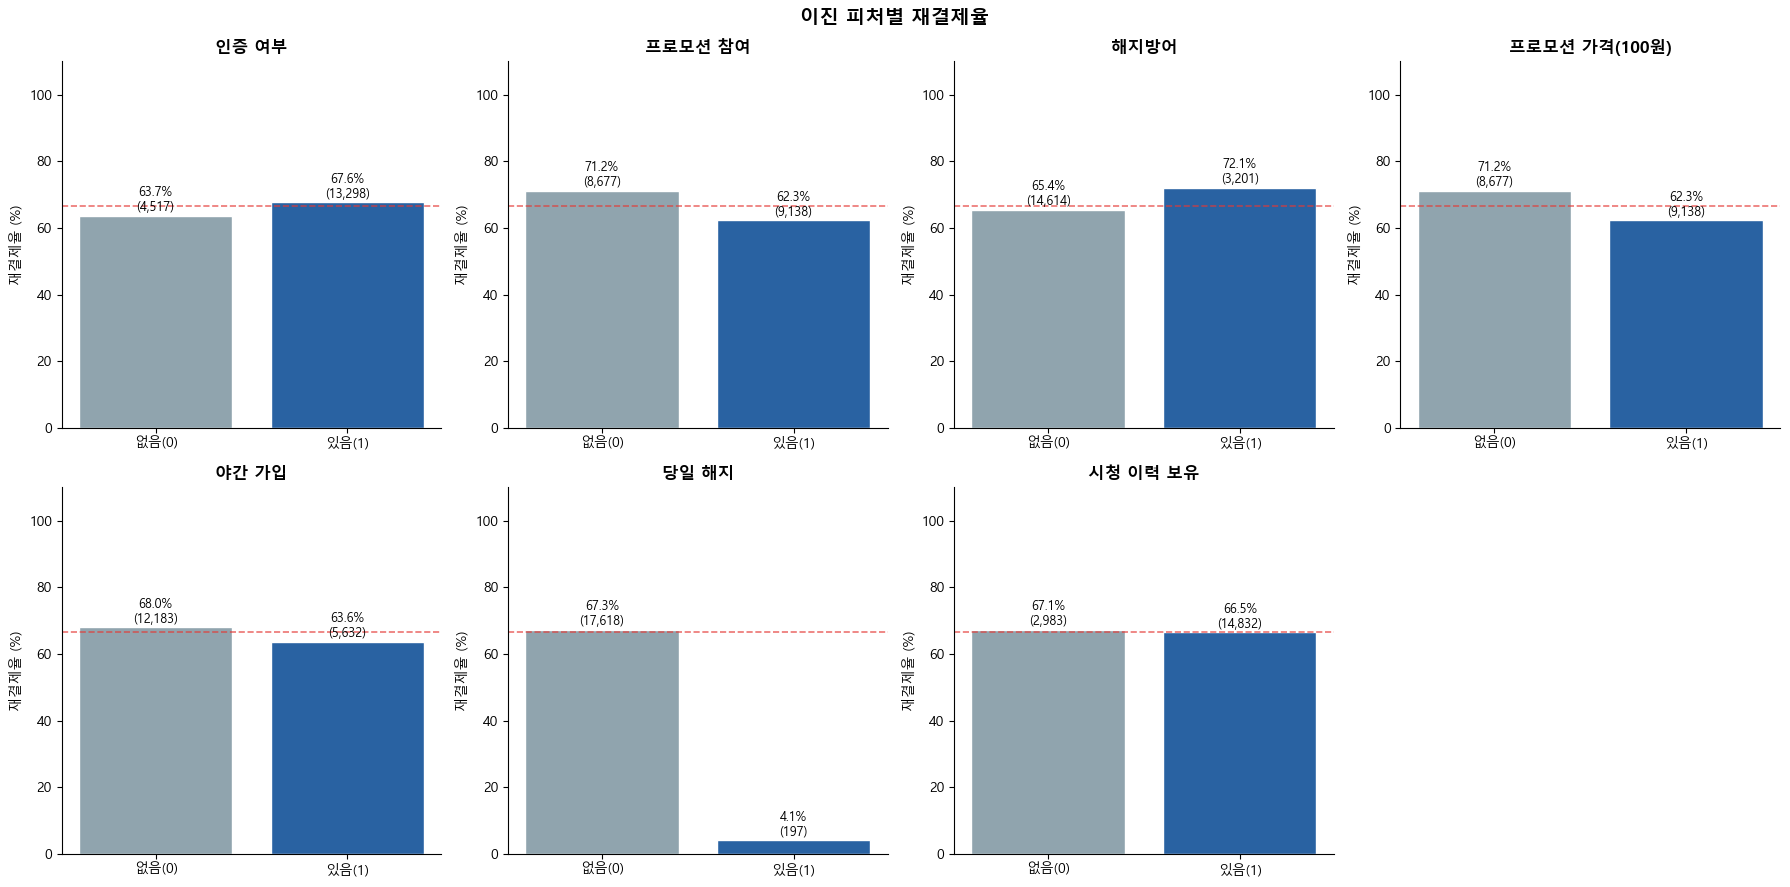

In [35]:
# 5. 이진 파생 피처별 재결제율
binary_feats = [
    ('is_verified',          '인증 여부'),
    ('promotion_yn',         '프로모션 참여'),
    ('is_churn_prevented',   '해지방어'),
    ('is_promotional_price', '프로모션 가격(100원)'),
    ('is_night_signup',      '야간 가입'),
    ('is_same_day_cancel',   '당일 해지'),
    ('has_watch_history',    '시청 이력 보유'),
]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('이진 피처별 재결제율', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()
avg = mem['repurchase'].mean() * 100
for i, (col, title) in enumerate(binary_feats):
    ax     = axes_flat[i]
    rates  = mem.groupby(col)['repurchase'].mean() * 100
    counts = mem[col].value_counts()
    yvals  = [rates.get(0, 0), rates.get(1, 0)]
    cnts   = [counts.get(0, 0), counts.get(1, 0)]
    bars = ax.bar(['없음(0)', '있음(1)'], yvals, color=[GRAY, BLUE], edgecolor='white')
    ax.axhline(avg, color=RED, linestyle='--', linewidth=1.2, alpha=0.7)
    for bar, v, cnt in zip(bars, yvals, cnts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}%\n({cnt:,})', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('재결제율 (%)')
    ax.spines[['top', 'right']].set_visible(False)
axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

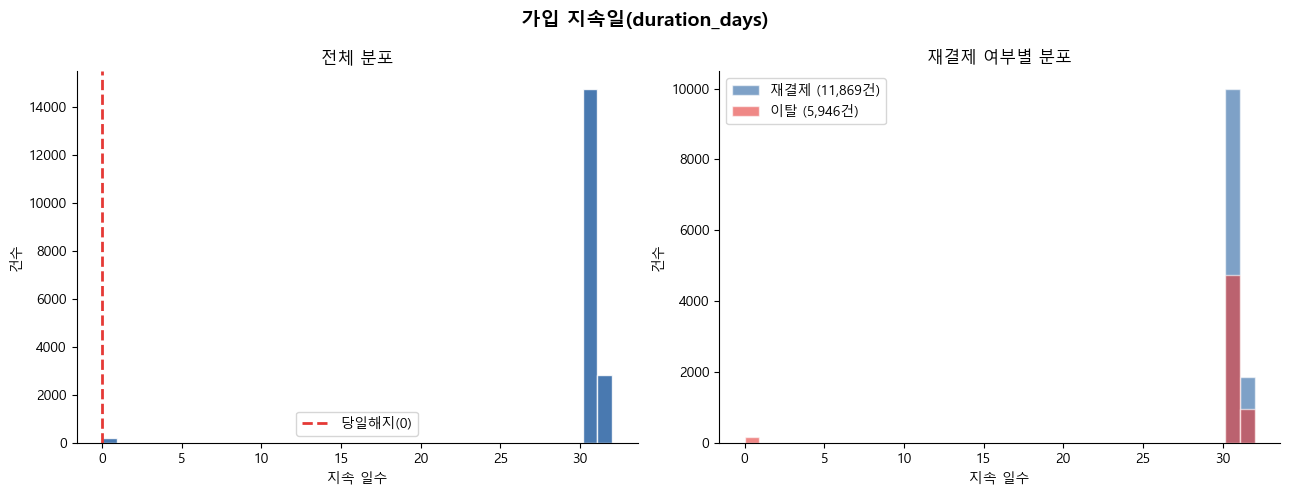

In [36]:
# 6. duration_days 분포 & 재결제 여부별
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('가입 지속일(duration_days)', fontsize=14, fontweight='bold')
axes[0].hist(mem['duration_days'], bins=35, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color=RED, linestyle='--', linewidth=2, label='당일해지(0)')
axes[0].set_xlabel('지속 일수')
axes[0].set_ylabel('건수')
axes[0].set_title('전체 분포')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)
for v, color, label in [(1, BLUE, '재결제'), (0, RED, '이탈')]:
    sub = mem[mem['repurchase'] == v]['duration_days']
    axes[1].hist(sub, bins=35, color=color, alpha=0.6,
                 label=f'{label} ({len(sub):,}건)', edgecolor='white')
axes[1].set_xlabel('지속 일수')
axes[1].set_ylabel('건수')
axes[1].set_title('재결제 여부별 분포')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

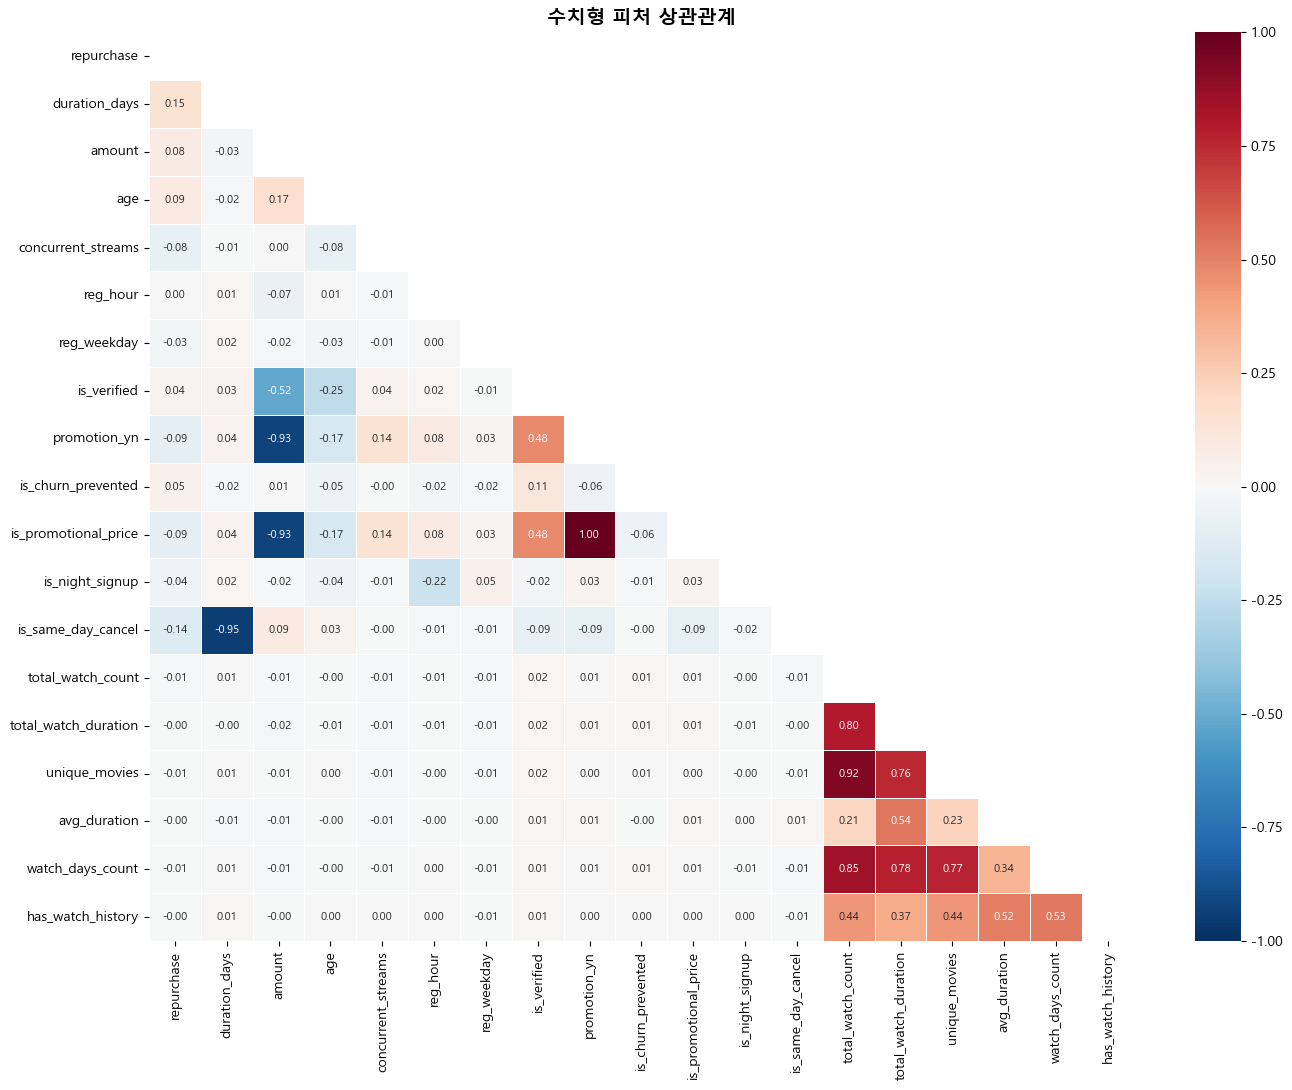

repurchase와 상관계수 (절댓값 내림차순):
duration_days           0.148
is_same_day_cancel      0.140
promotion_yn            0.094
is_promotional_price    0.094
age                     0.087
amount                  0.084
concurrent_streams      0.081
is_churn_prevented      0.054
is_night_signup         0.044
is_verified             0.036
reg_weekday             0.025
total_watch_count       0.011
unique_movies           0.007
watch_days_count        0.006
has_watch_history       0.005
total_watch_duration    0.004
reg_hour                0.001
avg_duration            0.001


In [37]:
# 7. 수치형 피처 상관관계 히트맵
num_cols = [
    'repurchase', 'duration_days', 'amount', 'age', 'concurrent_streams',
    'reg_hour', 'reg_weekday',
    'is_verified', 'promotion_yn', 'is_churn_prevented',
    'is_promotional_price', 'is_night_signup', 'is_same_day_cancel',
    'total_watch_count', 'total_watch_duration', 'unique_movies',
    'avg_duration', 'watch_days_count', 'has_watch_history',
]
num_cols = [c for c in num_cols if c in mem.columns]
corr = mem[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            ax=ax, annot_kws={'size': 8})
ax.set_title('수치형 피처 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('repurchase와 상관계수 (절댓값 내림차순):')
print(
    corr['repurchase'].drop('repurchase').abs()
       .sort_values(ascending=False).round(3).to_string()
)

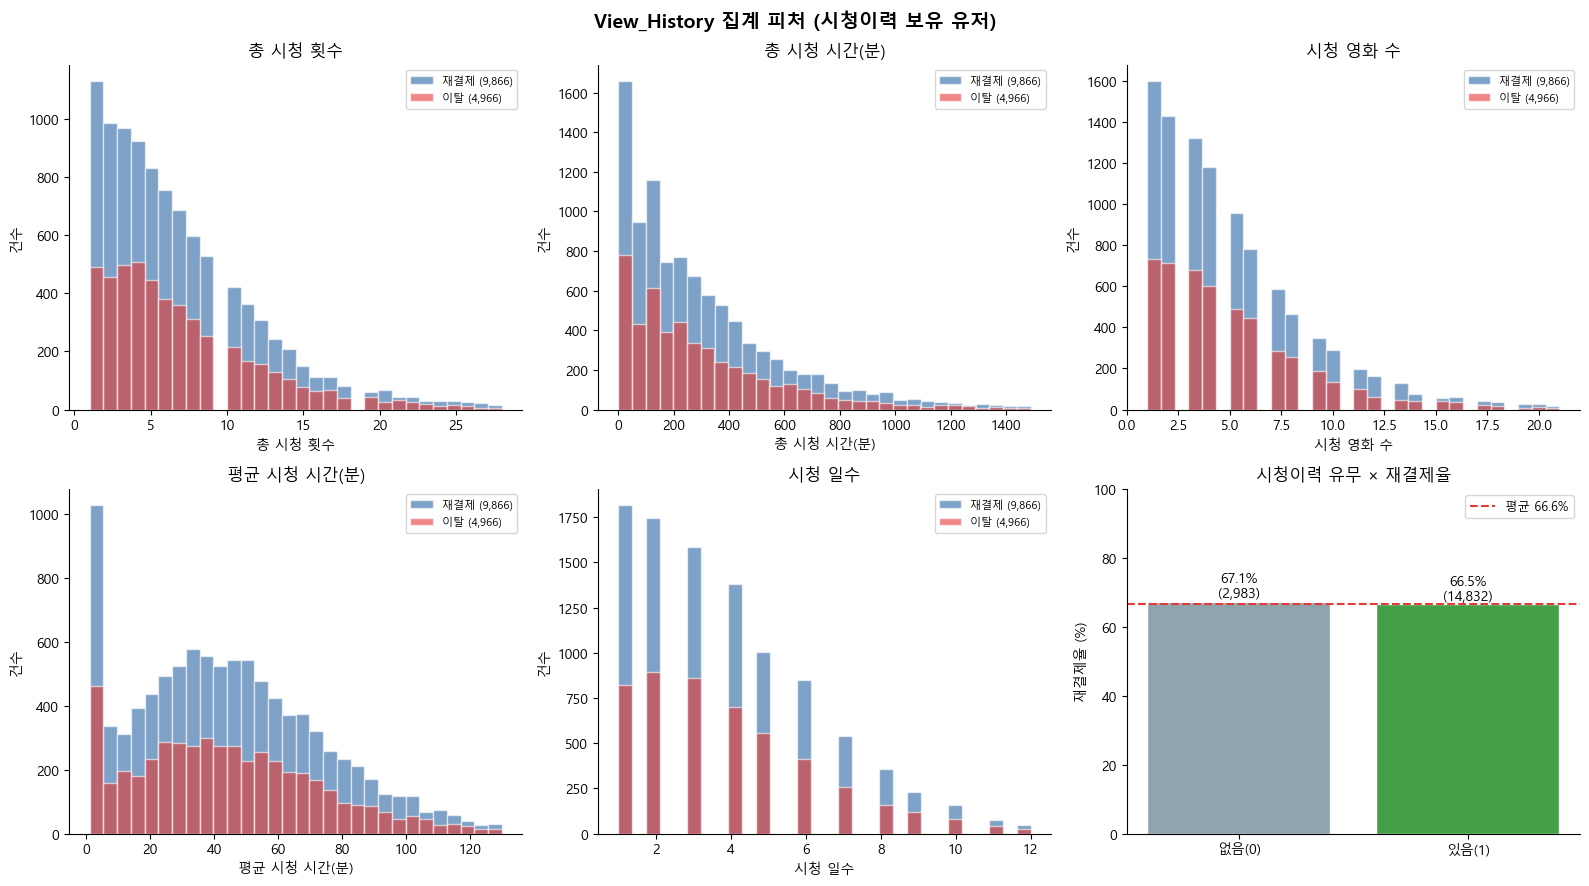

In [38]:
# 8. View_History 집계 피처 분포 & 시청이력 유무 × 재결제율
vh_users = mem[mem['has_watch_history'] == 1]
vh_feats = [
    ('total_watch_count',    '총 시청 횟수'),
    ('total_watch_duration', '총 시청 시간(분)'),
    ('unique_movies',        '시청 영화 수'),
    ('avg_duration',         '평균 시청 시간(분)'),
    ('watch_days_count',     '시청 일수'),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('View_History 집계 피처 (시청이력 보유 유저)', fontsize=14, fontweight='bold')
ax_flat = axes.flatten()
for i, (col, title) in enumerate(vh_feats):
    ax  = ax_flat[i]
    p99 = vh_users[col].quantile(0.99)
    for v, color, label in [(1, BLUE, '재결제'), (0, RED, '이탈')]:
        sub = vh_users[vh_users['repurchase'] == v][col]
        ax.hist(sub[sub <= p99], bins=30, color=color, alpha=0.6,
                label=f'{label} ({len(sub):,})', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('건수')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
ax = ax_flat[5]
rates  = mem.groupby('has_watch_history')['repurchase'].mean() * 100
counts = mem['has_watch_history'].value_counts()
bars   = ax.bar(['없음(0)', '있음(1)'],
                [rates.get(0, 0), rates.get(1, 0)],
                color=[GRAY, GREEN], edgecolor='white')
ax.axhline(mem['repurchase'].mean()*100, color=RED, linestyle='--', linewidth=1.5,
           label=f'평균 {mem["repurchase"].mean()*100:.1f}%')
for bar, k in zip(bars, [0, 1]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{rates.get(k,0):.1f}%\n({counts.get(k,0):,})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('시청이력 유무 × 재결제율')
ax.set_ylabel('재결제율 (%)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [39]:
print('=== 최종 데이터셋 ===')
print(f'Shape: {mem.shape}')
mem.head(3)

=== 최종 데이터셋 ===
Shape: (17815, 31)


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,...,is_night_signup,reg_weekday,is_same_day_cancel,age_group,total_watch_count,total_watch_duration,unique_movies,avg_duration,watch_days_count,has_watch_history
0,28d7d5684cce693a6a114cdabe2098875a894f3efaa4df...,pk_1508,11429.0,140,1,0,0,1,ios,N,...,0,5,0,40,16.0,718.0,12.0,44.875000,8.0,1
1,0da56ce994776bca14b522ab70bbfc70079fb34850fb4a...,pk_1508,11429.0,140,1,0,0,0,ios,N,...,0,1,0,30,4.0,287.0,4.0,71.750000,1.0,1
2,347d2fcd8e30072c1051fc617852bc7e70c13e3ecaac50...,pk_1508,11429.0,140,1,0,0,1,ios,N,...,0,5,0,40,3.0,124.0,3.0,41.333333,3.0,1
